# Assignment 1: Data Preparation — Bank Marketing Classification

https://github.com/Declamski/ML_foundations_data_preparation


Note: This notebook uses uv as a packet and project manager


This notebook covers the full data preparation pipeline for the UCI Bank Marketing dataset. The goal is to predict whether a client will subscribe to a term deposit (**y**). A term deposit is a fixed-term savings product where clients lock funds at a guaranteed interest rate, so the business question is: *"will this client subscribe after being contacted by the campaign?"*

Steps covered: target identification, exploration, task ordering, splitting, missing value handling, encoding, feature selection, scaling, class imbalance correction, and a baseline logistic regression model.

## Initial ordering of tasks

Before any preprocessing, three things need to happen first:

1. **Identifying the Prediction Target** — we need to know what we're predicting before we can reason about leakage, encoding, or feature relevance
2. **Data Loading and Exploration** — understanding the shape, types, distributions, and quality of the data informs every decision downstream
3. **Task Ordering** — getting the preprocessing sequence right prevents data leakage and keeps things reproducible

#### Imports
All imports are up here so that dependencies are visible at a glance and the notebook can be restarted and run top-to-bottom without hitting import errors halfway through.

In [244]:
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import OneHotEncoder
import numpy as np
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score, confusion_matrix, ConfusionMatrixDisplay


## Task 1: Identifying the Target Value

<p>Identify which feature should be treated as the target value.</p>

### Result

Besides the fact that it's labelled as "target" on the uci website, **y** is what we're looking for. We want to see if a client will subscribe to a term deposit, therefore, we should train our data on the target of subscribing to a term deposit which is what **y** is.

Two variables which could have been perceived as the target variable are:
- **poutcome**: This shows the outcome of the previous marketing campaign, however the data that we have is focused on **y** not **poutcome** so we'd be training our data on the wrong target. It also holds Categorical data while we're looking for a binary output
- **default**: Simply because I didn't know what it meant until this task, otherwise I don't feel as though there are any other features what would be reasonably mistaken as the target.

## Task 2: Data Loading and Exploration

We need to understand our dataset so that we can do feature engineering on it. If we don't understand the data then our feature engineering will be baseless.

In [245]:
data = pd.read_csv('data/bank-additional.csv')
data.head()

,age,job,marital,education,default,housing,loan,contact,month,day_of_week,...,campaign,pdays,previous,poutcome,emp.var.rate,cons.price.idx,cons.conf.idx,euribor3m,nr.employed,y
0,30,blue-collar,married,basic.9y,no,yes,no,cellular,may,fri,...,2,999,0,nonexistent,-1.8,92.893,-46.2,1.313,5099.1,no
1,39,services,single,high.school,no,no,no,telephone,may,fri,...,4,999,0,nonexistent,1.1,93.994,-36.4,4.855,5191.0,no
2,25,services,married,high.school,no,yes,no,telephone,jun,wed,...,1,999,0,nonexistent,1.4,94.465,-41.8,4.962,5228.1,no
3,38,services,married,basic.9y,no,unknown,unknown,telephone,jun,fri,...,3,999,0,nonexistent,1.4,94.465,-41.8,4.959,5228.1,no
4,47,admin.,married,university.degree,no,yes,no,cellular,nov,mon,...,1,999,0,nonexistent,-0.1,93.200,-42.0,4.191,5195.8,no


#### Initial Observations on Data
Below I inspect the dataset's shape, data types, and summary statistics to understand what we're working with before any transformation.

In [246]:
# Inspect the structure of the dataset
number_of_observations = data.shape[0]
number_of_features = data.shape[1] - 1 #-1 for the target variable

print(f"Number of observations: {number_of_observations}")
print(f"Number of features: {number_of_features}")
print("\nData types:")
print(data.dtypes)
print("\nBasic summary statistics:")
print(data.describe())

Number of observations: 4119
Number of features: 20

Data types:
age                 int64
job                   str
marital               str
education             str
default               str
housing               str
loan                  str
contact               str
month                 str
day_of_week           str
duration            int64
campaign            int64
pdays               int64
previous            int64
poutcome              str
emp.var.rate      float64
cons.price.idx    float64
cons.conf.idx     float64
euribor3m         float64
nr.employed       float64
y                     str
dtype: object

Basic summary statistics:
               age     duration     campaign        pdays     previous  \
count  4119.000000  4119.000000  4119.000000  4119.000000  4119.000000   
mean     40.113620   256.788055     2.537266   960.422190     0.190337   
std      10.313362   254.703736     2.568159   191.922786     0.541788   
min      18.000000     0.000000     1.000000     0.0

#### Separating Numerical and Categorical Features
I separate features by dtype — columns stored as `int64`/`float64` are treated as numerical, and `object` columns (excluding the target **y**) are treated as categorical. This separation drives later decisions about encoding and scaling.

In [247]:
# Identify numerical and categorical variables
numerical_features = data.select_dtypes(include=['int64', 'float64']).columns
categorical_features = data.select_dtypes(include=['object', 'str']).columns.drop('y', errors='ignore')

print(f"Numerical features ({len(numerical_features)}): {list(numerical_features)}")
print(f"\nCategorical features ({len(categorical_features)}): {list(categorical_features)}")

Numerical features (10): ['age', 'duration', 'campaign', 'pdays', 'previous', 'emp.var.rate', 'cons.price.idx', 'cons.conf.idx', 'euribor3m', 'nr.employed']

Categorical features (10): ['job', 'marital', 'education', 'default', 'housing', 'loan', 'contact', 'month', 'day_of_week', 'poutcome']


#### Distribution of our Target Variable 'y'
Understanding the target distribution early is important because a severe class imbalance can make a model look accurate while being useless (e.g. always predicting the majority class). Checking this here informs resampling decisions later.

Target distribution summary:


,Count,Percentage (%)
y,,
no,3668,89.05
yes,451,10.95


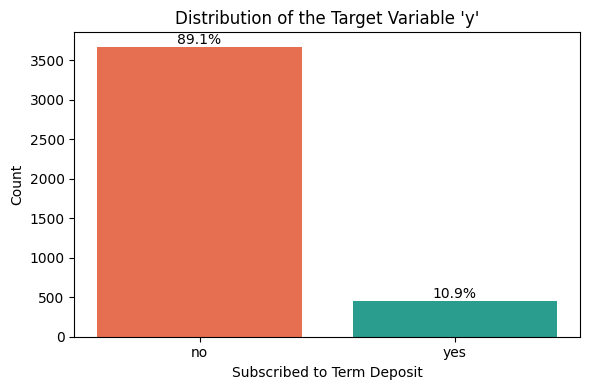

In [248]:
# Analyze the distribution of the target variable and show class percentages

y_counts = data['y'].value_counts()
y_pct = data['y'].value_counts(normalize=True) * 100

summary_df = pd.DataFrame({
    'Count': y_counts,
    'Percentage (%)': y_pct.round(2)
})

print('Target distribution summary:')
display(summary_df)

plt.figure(figsize=(6, 4))
plt.bar(y_counts.index, y_counts.values, color=['#e76f51', '#2a9d8f'])
plt.xlabel('Subscribed to Term Deposit')
plt.ylabel('Count')
plt.title("Distribution of the Target Variable 'y'")

# Annotate bars with percentages
for i, cls in enumerate(y_counts.index):
    plt.text(i, y_counts.values[i], f"{y_pct[cls]:.1f}%", ha='center', va='bottom')

plt.tight_layout()
plt.show()

#### Detecting Implicit and Explicit Missing Values
- **Explicit** missing values are native `NaN`/`None` entries that pandas picks up automatically
- **Implicit** missing values are domain-specific sentinels (e.g. `'unknown'` in categorical columns, `999` in **pdays**) that *look* like real data but actually represent absence of information

I check for both types below so nothing slips through.

In [249]:
# Detect explicit and implicit missing values
missing_data = {
    'job': 'unknown',
    'marital': 'unknown',
    'education': 'unknown',
    'default': 'unknown',
    'housing': 'unknown',
    'loan': 'unknown'
}

missing_summary = []

for col in data.columns:
    # Explicit missing values (NaN/NA already present in the dataset)
    explicit_missing_count = data[col].isna().sum()

    # Implicit missing values (special placeholders such as 'unknown')
    implicit_missing_count = 0
    missing_type = missing_data.get(col, 'N/A')
    if col in missing_data:
        implicit_missing_count = (data[col] == missing_data[col]).sum()

    missing_count = explicit_missing_count + implicit_missing_count

    if missing_count > 0:  # Only include columns with missing values
        missing_pct = (missing_count / len(data)) * 100

        missing_summary.append({
            'Column': col,
            'Missing_Type': missing_type,
            'Count': missing_count,
            'Percentage': f'{missing_pct:.1f}%'
        })

missing_df = pd.DataFrame(missing_summary)
display(missing_df)

,Column,Missing_Type,Count,Percentage
0,job,unknown,39,0.9%
1,marital,unknown,11,0.3%
2,education,unknown,167,4.1%
3,default,unknown,803,19.5%
4,housing,unknown,105,2.5%
5,loan,unknown,105,2.5%


#### Investigating the High Unknown Rate in `default`
With ~20% of **default** values being `unknown`, there may be a systematic pattern — for example, clients who have defaulted might be less willing to disclose that. I cross-tabulate **default** categories against the target below to see whether the unknown group behaves differently from `no` or `yes`.

Counts of y within each default category:


y,no,yes
default,,
no,2913,402
unknown,754,49
yes,1,0


Percentages of y within each default category:


y,no,yes
default,,
no,87.87,12.13
unknown,93.90,6.10
yes,100.00,0.00


<Figure size 800x500 with 0 Axes>

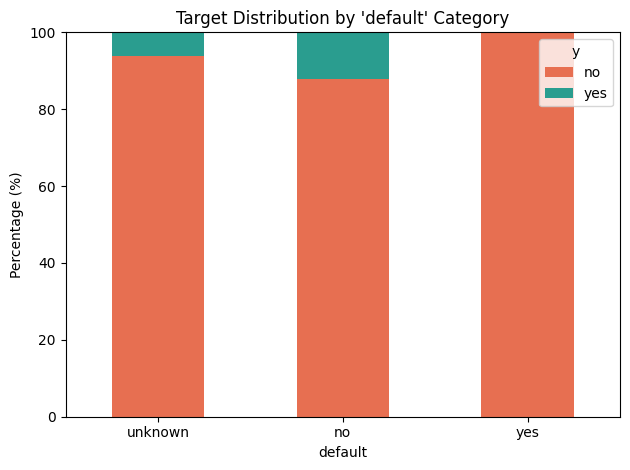

In [250]:
# Relationship between 'default' category and target variable 'y'

default_target_counts = pd.crosstab(data['default'], data['y'])
default_target_pct = pd.crosstab(data['default'], data['y'], normalize='index') * 100

print("Counts of y within each default category:")
display(default_target_counts)

print("Percentages of y within each default category:")
display(default_target_pct.round(2))

# Visualize percentage split (no vs yes) for default categories
plt.figure(figsize=(8, 5))
default_target_pct.reindex(['unknown', 'no', 'yes']).fillna(0).plot(
    kind='bar',
    stacked=True,
    color=['#e76f51', '#2a9d8f']
)
plt.title("Target Distribution by 'default' Category")
plt.xlabel("default")
plt.ylabel("Percentage (%)")
plt.legend(title='y', loc='upper right')
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

#### Visualizing distributions of Numerical and Categorical Values

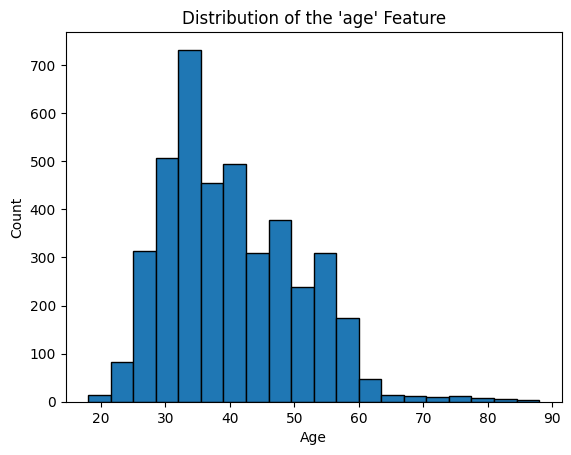

In [251]:
# Age
plt.hist(data.age, bins=20, edgecolor='black')
plt.xlabel('Age')
plt.ylabel('Count')
plt.title("Distribution of the 'age' Feature")
plt.show()

#### Duration: Distribution and Target Relationship
**duration** records the length of the last marketing call in seconds. I want to check whether zero-duration calls (no actual contact) always result in `no`, and whether longer calls correlate with higher subscription rates. This is also a feature flagged for removal later since it's only known *after* the call ends.

Counts: duration == 0 vs duration > 0 by target


y,no,yes
duration_is_zero,,
False,3667,451
True,1,0


Row percentages (%):


y,no,yes
duration_is_zero,,
False,89.05,10.95
True,100.00,0.00


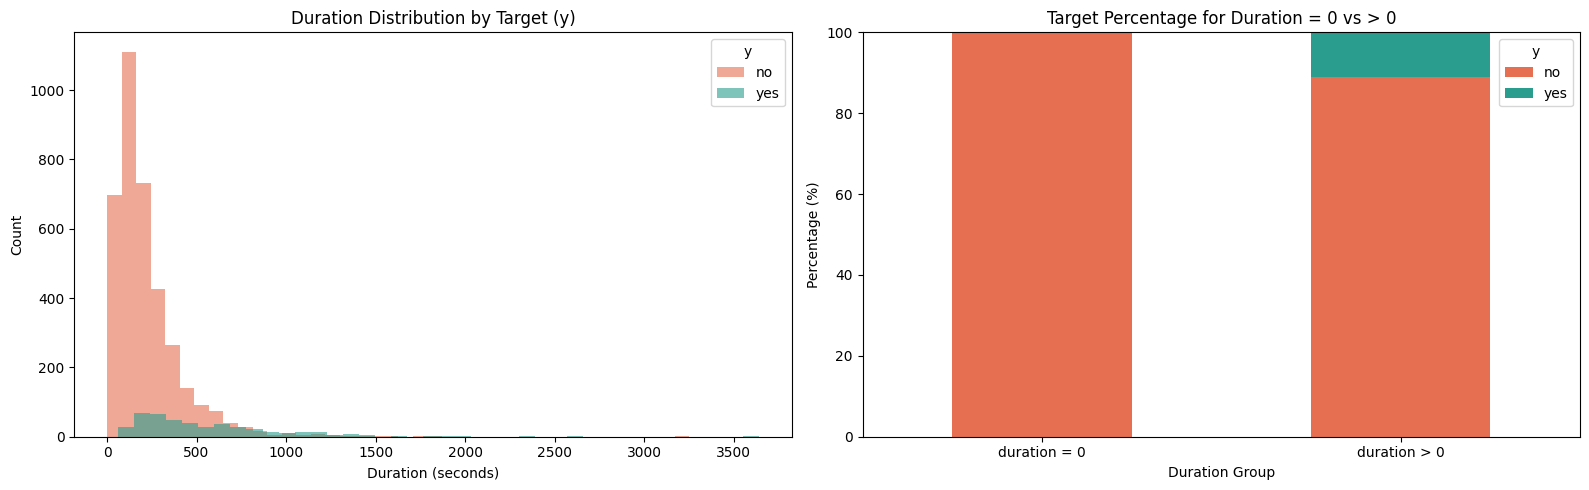

In [252]:
# Compare duration distribution with the target variable (y)
duration_target = data[['duration', 'y']].copy()
duration_target['duration_is_zero'] = duration_target['duration'] == 0

# Show count and row-percentage table for duration == 0 vs duration > 0 by target value
zero_count_table = pd.crosstab(duration_target['duration_is_zero'], duration_target['y'])
zero_pct_table = pd.crosstab(duration_target['duration_is_zero'], duration_target['y'], normalize='index') * 100

print('Counts: duration == 0 vs duration > 0 by target')
display(zero_count_table)

print('Row percentages (%):')
display(zero_pct_table.round(2))

fig, axes = plt.subplots(1, 2, figsize=(16, 5))

# 1) Distribution of duration split by target
for target_value, color in [('no', '#e76f51'), ('yes', '#2a9d8f')]:
    subset = duration_target.loc[duration_target['y'] == target_value, 'duration']
    axes[0].hist(subset, bins=40, alpha=0.6, label=target_value, color=color)

axes[0].set_title('Duration Distribution by Target (y)')
axes[0].set_xlabel('Duration (seconds)')
axes[0].set_ylabel('Count')
axes[0].legend(title='y')

# 2) Stacked percentage bar for duration==0 vs duration>0
plot_pct = zero_pct_table.reindex([True, False]).fillna(0)
plot_pct.index = ['duration = 0', 'duration > 0']
plot_pct.plot(kind='bar', stacked=True, ax=axes[1], color=['#e76f51', '#2a9d8f'])
axes[1].set_title('Target Percentage for Duration = 0 vs > 0')
axes[1].set_xlabel('Duration Group')
axes[1].set_ylabel('Percentage (%)')
axes[1].legend(title='y', loc='upper right')
axes[1].tick_params(axis='x', rotation=0)

plt.tight_layout()
plt.show()

#### Month Distribution
Below I plot how calls are distributed across calendar months to identify any seasonal patterns in campaign activity.

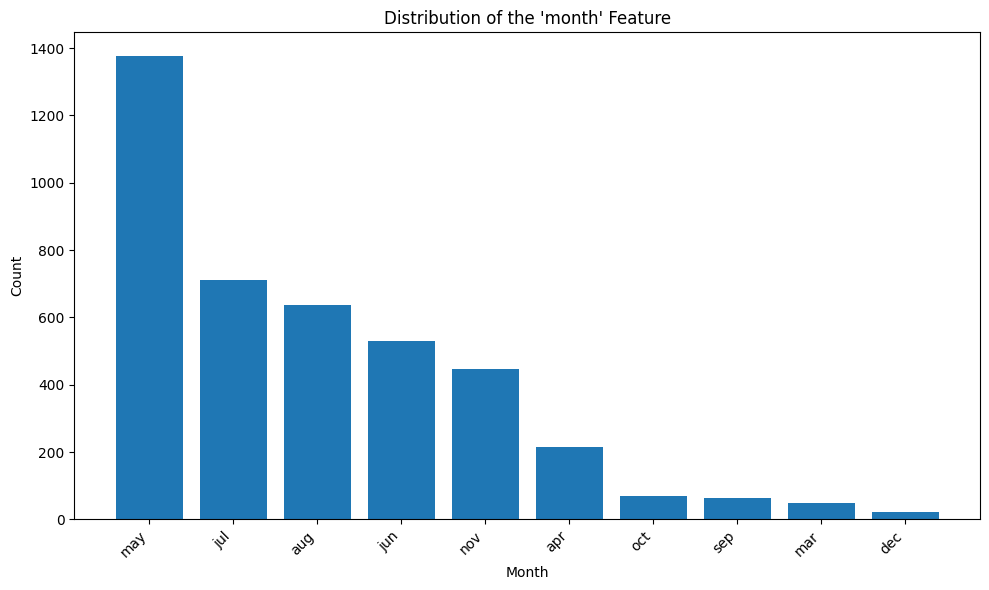

In [253]:
# Visualize the distribution of categorical variables

# Month
plt.figure(figsize=(10, 6))
plt.bar(data.month.value_counts().index, data.month.value_counts().values)
plt.xlabel('Month')
plt.ylabel('Count')
plt.title("Distribution of the 'month' Feature")
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

#### Categorical Variable Distributions
Detailed observations on all categorical and numerical distributions are consolidated in the **Results** section below. The following cells visualize **job**, **pdays**, and their relationship with the target.

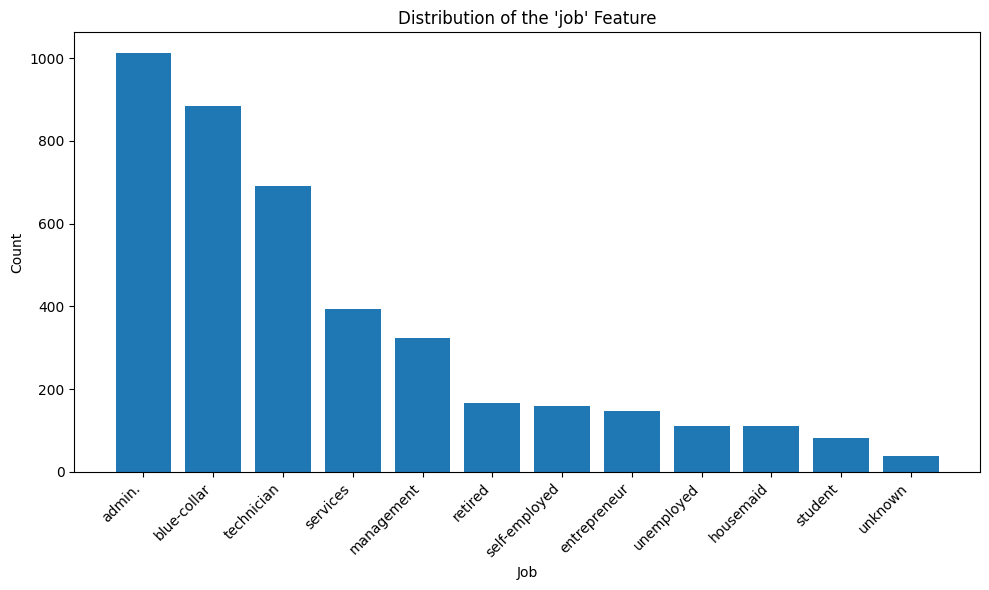

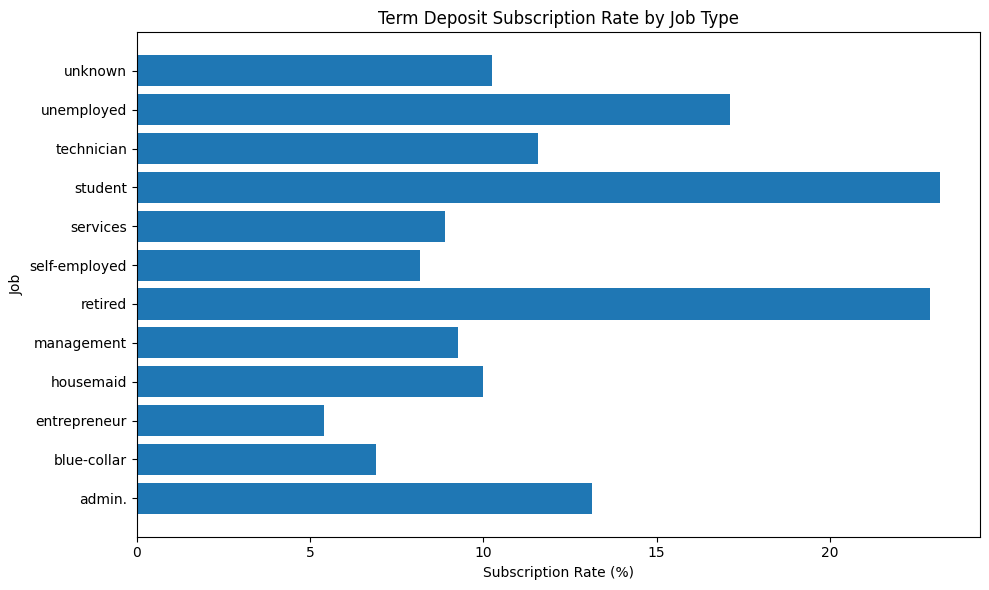

In [254]:
# Job
plt.figure(figsize=(10, 6))
plt.bar(data.job.value_counts().index, data.job.value_counts().values)
plt.xlabel('Job')
plt.ylabel('Count')
plt.title("Distribution of the 'job' Feature")
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

# Additional Analysis: Term Deposit Subscription Rate by Job Type
job_y_rate = data.groupby('job')['y'].apply(lambda x: (x == 'yes').sum() / len(x) * 100)
plt.figure(figsize=(10, 6))
plt.barh(job_y_rate.index, job_y_rate.values)
plt.xlabel('Subscription Rate (%)')
plt.ylabel('Job')
plt.title('Term Deposit Subscription Rate by Job Type')
plt.tight_layout()
plt.show()

#### pdays: Sentinel Value and Target Relationship
**pdays** records the number of days since the client was last contacted in a *previous* campaign, with `999` meaning the client was never contacted. I check the skew toward `999` and whether prior contact strongly predicts subscription.

How skewed pdays is toward 999:


,Count,Percentage (%)
pdays,,
pdays = 999,3959,96.12
pdays < 999,160,3.88


Counts of y within each pdays group:


y,no,yes
pdays,,
pdays < 999,60,100
pdays = 999,3608,351


Percentages of y within each pdays group:


y,no,yes
pdays,,
pdays < 999,37.50,62.50
pdays = 999,91.13,8.87


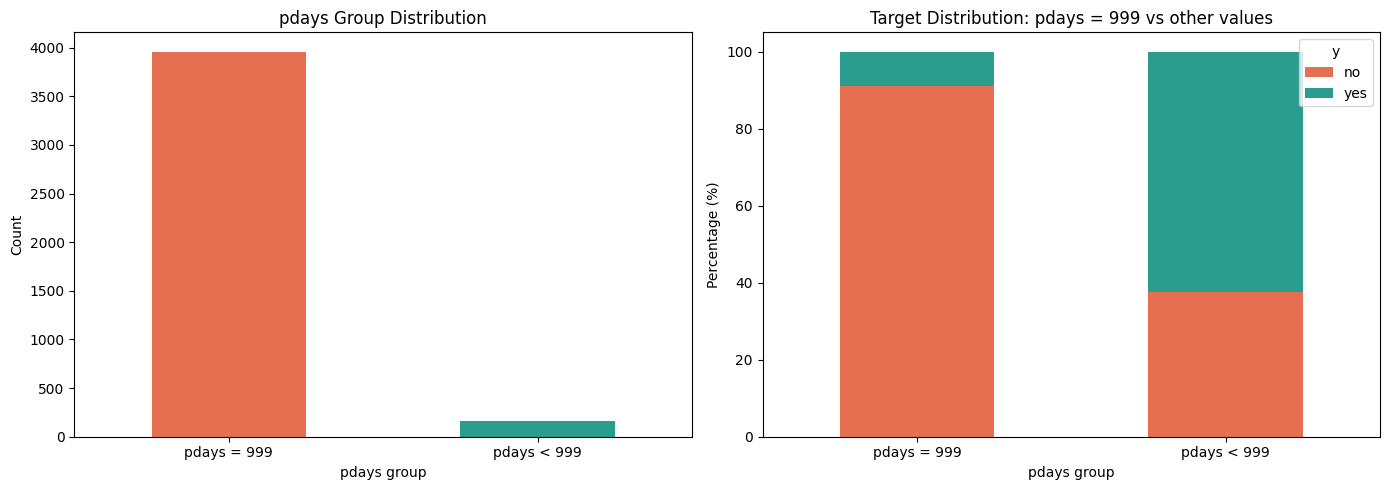

In [255]:
# Distribution of pdays and subscription comparison for 999 vs other values
pdays_group = data['pdays'].eq(999).map({True: 'pdays = 999', False: 'pdays < 999'})

# Count and percentage of pdays groups
pdays_group_counts = pdays_group.value_counts()
pdays_group_pct = (pdays_group_counts / len(data) * 100).round(2)

pdays_group_summary = pd.DataFrame({
    'Count': pdays_group_counts,
    'Percentage (%)': pdays_group_pct
})

print('How skewed pdays is toward 999:')
display(pdays_group_summary)

# Target distribution within each pdays group
pdays_target_counts = pd.crosstab(pdays_group, data['y'])
pdays_target_pct = pd.crosstab(pdays_group, data['y'], normalize='index') * 100

print('Counts of y within each pdays group:')
display(pdays_target_counts)

print('Percentages of y within each pdays group:')
display(pdays_target_pct.round(2))

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# 1) Show skew toward 999
pdays_group_counts.reindex(['pdays = 999', 'pdays < 999']).plot(
    kind='bar',
    ax=axes[0],
    color=['#e76f51', '#2a9d8f']
)
axes[0].set_title('pdays Group Distribution')
axes[0].set_xlabel('pdays group')
axes[0].set_ylabel('Count')
axes[0].tick_params(axis='x', rotation=0)

# 2) Show subscription rate split for 999 vs others
pdays_target_pct.reindex(['pdays = 999', 'pdays < 999']).plot(
    kind='bar',
    stacked=True,
    ax=axes[1],
    color=['#e76f51', '#2a9d8f']
)
axes[1].set_title('Target Distribution: pdays = 999 vs other values')
axes[1].set_xlabel('pdays group')
axes[1].set_ylabel('Percentage (%)')
axes[1].legend(title='y', loc='upper right')
axes[1].tick_params(axis='x', rotation=0)

plt.tight_layout()
plt.show()

#### Results

The dataset has 4119 entries of 20 features + target variable

Within these 20 features, half are numerical and half are categorical

**Target Variable Analysis**
- The target variable **y** is heavily skewed towards 'no' with an almost 90% to 10% split favoring 'no'
- Due to this class imbalance, our model could end up only predicting 'no' with an accuracy of 90%. Although this 90% may look good initially, the model would be rendered useless.
- This will need to be addressed later with methods such as random oversampling, SMOTE or ADASYN

**Missing Values**
- Although our dataset contains no explicit missing values (NaN), we have 6 categorical features which can contain entries with the value 'unknown'
- Although most features have low percentages of unknown rates within the entries, **default** has a 20% unknown rate. This could suggest a pattern that should be looked into as opposed to a random absence of data.
    - Due to this, I plotted the distribution of **y** across **default** categories however it showed no clear pattern. Although nothing was found, the high percentage of missing values still suggests that the feature should be handled more carefully.

**Distributions of Categorical and Numerical Variables**

Age
- Hypothesis: I expected the age distribution to peak at around 40-50 as clients have more years of income growth and therefore a high ability to subscribe to a term deposit
- Conclusion: The age distribution peaked at 30-40 with count increasing in the mid 20s and trailing in the mid 50s. They may suggest that the campaign was designed to reach people in this age range or the client base of the company is higher in these ages.

Duration
- Hypothesis: Any entries with a value of **0** will always result in a target value of **0** as it means the campaign hasn't reached the client. For **non-zero entries**, the longer the duration is the higher the percentage of **yes** is it suggest that the client is more interested.
- Conclusion: Values of **0** did indeed result in a 100% rate of **no** on the target variable. I can also conclude that the other assumption of longer calls to higher percentages of **yes** is correct due to the relative sizes of green to orange bars in the bar chart labeled **Duration Distribution by Target (y)**

Month
- Hypothesis: Summer and Winter months will result in less calls as they are seasons where spending is typically higher due to vacation, because of this I expect that the company will call more during the months between them as clients will be more likely to spend.
- Conclusion: Summer months turn out to be peak times for calls. Why this is I'm unsure, possibly due to more free time due to vacation so a higher likelihood that clients are willing to spend time to listen.

Job
- Hypothesis: The job of clients will be distributed somewhat evenly to what the general population, meaning more **admin**, **blue collar** and **services**. They will likely target less people of low income such as **students** and the **unemployed**.
- Conclusion: The count reflects the hypothesis. Interestingly enough, **students** and **retired** have the highest percentage of subscription rate. This could be because they don't have jobs and are more interested in investing the money that they have.

**Variable requiring special consideration**

pdays
- pdays has a clear skew towards **999** with a ~96% skew towards the value. I initially thought it was an implicit missing value but later realized it was in fact clearly showing something in the data. The distribution of the target based on whether pdays **=999** or **!=999** is extreme, suggesting that its correlation is too closely related to the target variable and it may need to be dropped later in feature selection.

## Task 3: Task Ordering

Determine the correct ordering of tasks. This is based on how different tasks affect others which could lead to poor feature engineering


#### The Order
- Data Splitting
- Managing Missing Values
- Encoding Categorical Values
- Feature Selection
- Feature Scaling
- Addressing Class Imbalance
- Training a Logistic Regression Model

#### Explanation
1. **Data Splitting**
   
   To prevent any information from validation/test data influencing preprocessing or model training.
- Allowed:
    - Full access to the dataset so it can be split accordingly
    - Class distributions so that when the data is split is proportional across the splits
- Not Allowed:
    - Statistics as it tells us something about the data, letting us see "future data" when the validation and test subsets are meant to imitate future data
- Data Leakage due to misordering:
    - Temporal Leakage

2. **Managing Missing Values**

    Imputation learns statistics but these must be learned only from training data.
- Allowed:
    - Training Set
- Not Allowed:
    - Validation and Test Sets
    - Target Value
- Data Leakage due to misordering:
    - Temporal Leakage

3. **Encoding Categorical Values**

    Models require numeric input, encoding must happen after missing value handling.
- Allowed:
    - Training Categorical Values
- Not Allowed: 
    - Validation and Test sets
    - Target based encodings
- Data Leakage due to misordering
    - Temporal Leakage

4. **Feature Selection**

    After encoding, all variables are numeric and comparable.
- Allowed:
    - Training features
    - Training targets
    - Any statistical tests or correlations with the target
- Not Allowed:
    - Validation and Test sets
    - Correlations with non-training set data
- Data Leakage due to misordering
    - Target Leakage

5. **Feature Scaling**

    Logistic regression is scale sensitive, scaling ensures features are comparable.
- Allowed:
    - Statistics on the training set
- Not Allowed:
    - Statistics on the validation and test sets
- Data Leakage due to misordering
    - Temporal Leakage

6. **Addressing Class Imbalance**
- Allowed: 
    - Training set
- Not Allowed:
    - Validation and Test sets
- Data Leakage due to misordering:
    - Temporal Leakage

7. **Training Logistic Regression Model**

    Final step after clean, transformed, balanced training data.
- Allowed:
    - Training set
- Not Allowed:
    - Validation and Test sets
- Data Leakage due to misordering:
    - Temporal Leakage



**Note:** Any step where the Target Value is not allowed is due to target leakage. The task only requires us to point out leakage due to misordering however I thought it important to clarify.

#### Example of misordering
Encoding categorical variables before managing missing values is incorrect because most encoders can't handle NaN values properly and may treat them as their own category. This messes up the feature space and makes imputation afterwards inconsistent since the missing values aren't at the original feature level anymore. Because of this, missing values need to be dealt with before encoding so that the features still make sense when the encoder processes them.

## Task 4: Data Splitting

The dataset must be split into training, validation, and test sets *before* any preprocessing. This keeps our validation and test sets completely unseen during feature engineering so we don't get temporal leakage. Everything we learn during preprocessing (imputation values, encoder categories, scaling parameters, resampling) comes from the training set only.

In [256]:
# Split into 70% train and 30% temporary (test + val)
train, temp = train_test_split(data, test_size=0.30, random_state=42, stratify=data['y'])

# Split the temporary set into 50% test and 50% val (each is 15% of original)
test, val = train_test_split(temp, test_size=0.5, random_state=42, stratify=temp['y'])

# Display split sizes
print("Data Split Summary:")
print(f"Training set: {len(train)} samples ({len(train)/len(data)*100:.1f}%)")
print(f"Test set: {len(test)} samples ({len(test)/len(data)*100:.1f}%)")
print(f"Validation set: {len(val)} samples ({len(val)/len(data)*100:.1f}%)")
print(f"\nTotal samples: {len(train) + len(test) + len(val)}")

# Show target distribution in each split
print("\n\nTarget Distribution by Split:")
print("\nTrain:")
print(train['y'].value_counts(normalize=True) * 100)
print("\nTest:")
print(test['y'].value_counts(normalize=True) * 100)
print("\nValidation:")
print(val['y'].value_counts(normalize=True) * 100)

Data Split Summary:
Training set: 2883 samples (70.0%)
Test set: 618 samples (15.0%)
Validation set: 618 samples (15.0%)

Total samples: 4119


Target Distribution by Split:

Train:
y
no     89.039195
yes    10.960805
Name: proportion, dtype: float64

Test:
y
no     88.996764
yes    11.003236
Name: proportion, dtype: float64

Validation:
y
no     89.158576
yes    10.841424
Name: proportion, dtype: float64


#### Result

**Split Justification**

I have chosen a 70-15-15 split because:
- With 4,119 samples, we have enough to use 70% of our dataset as opposed to another value such as 80%
- This allows us to have ~600 samples for each our test and validation sets, this is a much more reliable number of samples than the ~400 that an 80-10-10 split would have given
- This gives us ~65 "yes" results on the target variable for our test and validation sets, a much more reliable number than the ~40 that 80-10-10 would have given

**Importance of Stratified Splitting**

Stratified splitting ensures that each data set has the same distribution of target variables. This removes randomness, ensuring that our numbers reflect real world evaluation in each dataset.

**What Stage in the Pipeline?**

After loading and exploring data, splitting must happen because preprocessing must take place solely on our training data. Test and validation sets are meant to simulate future values, this means that if feature engineering is done on our dataset as a whole then temporal leakage will occur as the model is being trained on test and validation data as well as training data.

## Task 5: Managing Missing Values

Missing values can distort learned patterns if not handled properly. This step identifies and addresses both explicit (`NaN`) and implicit (`'unknown'`, `999`) missingness. All decisions here are based solely on the training set to prevent data leakage.

In [257]:
explicit_missing = train.isnull().sum()
explicit_missing = explicit_missing[explicit_missing > 0]

if explicit_missing.empty:
    print("No explicit NaN values found in the training set.\n")
else:
    explicit_df = pd.DataFrame({
        'Count': explicit_missing,
        'Percentage (%)': (explicit_missing / len(train) * 100).round(2)
    })
    display(explicit_df)

implicit_results = []

categorical_cols = train.select_dtypes(include=['object', 'str']).columns.drop('y', errors='ignore')

for col in categorical_cols:
    unknown_count = (train[col] == 'unknown').sum()
    if unknown_count > 0:
        pct = unknown_count / len(train) * 100
        implicit_results.append({
            'Feature': col,
            'Type': 'implicit missing',
            'Sentinel Value': "'unknown'",
            'Count': unknown_count,
            'Percentage (%)': round(pct, 2)
        })

pdays_999 = (train['pdays'] == 999).sum()
implicit_results.append({
    'Feature': 'pdays',
    'Type': 'sentinel numerical',
    'Sentinel Value': '999 (no prior contact)',
    'Count': pdays_999,
    'Percentage (%)': round(pdays_999 / len(train) * 100, 2)
})

implicit_df = pd.DataFrame(implicit_results).sort_values('Percentage (%)', ascending=False)
display(implicit_df.reset_index(drop=True))

No explicit NaN values found in the training set.



,Feature,Type,Sentinel Value,Count,Percentage (%)
0,pdays,sentinel numerical,999 (no prior contact),2764,95.87
1,default,implicit missing,'unknown',577,20.01
2,education,implicit missing,'unknown',112,3.88
3,housing,implicit missing,'unknown',65,2.25
4,loan,implicit missing,'unknown',65,2.25
5,job,implicit missing,'unknown',25,0.87
6,marital,implicit missing,'unknown',7,0.24


#### Results
**Strategy**

1. Explicit Missing Values

No explicit missing values were found in the dataset, thus no action is needed.

2. Implicit Missing Values

In this dataset, there are 6 categorical values with the value **unknown** as stated earlier in data loading and exploration. 
- Data Cleaning: **unknown** was a choice by the creators of the dataset, it may well carry meaning itself. Therefore trying to fill in gaps would only be inventing data, not estimating it.
- Modeling: Missingness may be predictable, if there is a statistical likelihood between 2 or more variables where one is unknown then the model may learn this.

3. Sentinel Numerical Values

In the documentation, a value of **999** for pdays is a sentinel for "not contacted".
- Data cleaning: Leaving pdays as numerical would confuse the model as the importance of the feature isn't the exact amount of days and it has an extremely heavy skew towards **999**.
- Strategy: Using a binary indicator such as **1** = **contacted** | **0** = **not contacted** would give a better understanding to the model on what the feature is showing.
- Modeling: With use of our new binary indicator, pdays will be dropped.

## Task 6: Encoding Categorical Values

Models require numeric input. Categorical features must be converted into numbers in a way that preserves their meaning — ordinal features get rank-based encoding while nominal features get one-hot encoding to avoid implying false numeric relationships. The encoder is fitted on the training set only and then applied to validation and test sets.

In [258]:
print(categorical_features)

X_train = train.drop(columns='y').copy()
X_test = test.drop(columns='y').copy()
X_val = val.drop(columns='y').copy()

y_train = train['y'].copy()
y_test = test['y'].copy()
y_val = val['y'].copy()

# Replace pdays with a binary indicator (1 = previously contacted, 0 = not contacted)
for split in [X_train, X_test, X_val]:
    split['pdays_contacted'] = (split['pdays'] != 999).astype(int)
    split.drop(columns='pdays', inplace=True)

# Ordinal encoding for education using a meaningful ranking
education_order = [
    'illiterate',
    'basic.4y',
    'basic.6y',
    'basic.9y',
    'high.school',
    'professional.course',
    'university.degree'
]
education_mapping = {level: index for index, level in enumerate(education_order)}

for split in [X_train, X_test, X_val]:
    split['education_unknown'] = (split['education'] == 'unknown').astype(int)
    split['education_encoded'] = split['education'].map(education_mapping).fillna(-1)
    split.drop(columns='education', inplace=True)

# One-hot encode nominal variables using categories learned from the training set only
nominal_features = [
    'job', 'marital', 'default', 'housing', 'loan',
    'contact', 'month', 'day_of_week', 'poutcome'
]

onehot_encoder = OneHotEncoder(handle_unknown='ignore', sparse_output=False)
train_nominal = onehot_encoder.fit_transform(X_train[nominal_features])
test_nominal = onehot_encoder.transform(X_test[nominal_features])
val_nominal = onehot_encoder.transform(X_val[nominal_features])

encoded_columns = onehot_encoder.get_feature_names_out(nominal_features)

train_nominal_df = pd.DataFrame(train_nominal, columns=encoded_columns, index=X_train.index)
test_nominal_df = pd.DataFrame(test_nominal, columns=encoded_columns, index=X_test.index)
val_nominal_df = pd.DataFrame(val_nominal, columns=encoded_columns, index=X_val.index)

# Combine encoded categorical features with the remaining numeric features
X_train_encoded = pd.concat([X_train.drop(columns=nominal_features), train_nominal_df], axis=1)
X_test_encoded = pd.concat([X_test.drop(columns=nominal_features), test_nominal_df], axis=1)
X_val_encoded = pd.concat([X_val.drop(columns=nominal_features), val_nominal_df], axis=1)

print(f'Train shape after encoding: {X_train_encoded.shape}')
print(f'Test shape after encoding: {X_test_encoded.shape}')
print(f'Validation shape after encoding: {X_val_encoded.shape}')
print(f'\nNumber of encoded features: {X_train_encoded.shape[1]}')

display(X_train_encoded.head())

Index(['job', 'marital', 'education', 'default', 'housing', 'loan', 'contact',
       'month', 'day_of_week', 'poutcome'],
      dtype='str')
Train shape after encoding: (2883, 57)
Test shape after encoding: (618, 57)
Validation shape after encoding: (618, 57)

Number of encoded features: 57


,age,duration,campaign,previous,emp.var.rate,cons.price.idx,cons.conf.idx,euribor3m,nr.employed,pdays_contacted,...,month_oct,month_sep,day_of_week_fri,day_of_week_mon,day_of_week_thu,day_of_week_tue,day_of_week_wed,poutcome_failure,poutcome_nonexistent,poutcome_success
1948,49,128,8,0,1.4,93.444,-36.1,4.966,5228.1,0,...,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0
2198,44,170,2,0,1.4,93.918,-42.7,4.963,5228.1,0,...,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0
166,32,374,2,0,-1.8,92.893,-46.2,1.313,5099.1,0,...,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0
2152,44,182,1,0,-0.1,93.200,-42.0,4.153,5195.8,0,...,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0
2881,33,399,1,0,-1.8,92.893,-46.2,1.344,5099.1,0,...,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0


#### Result
- Before encoding: 20 input features
- After encoding: 57 input features
- All 10 categorical features were dropped:
    - Added 2 from Ordinal features
    - Added 45 from Nominal features
- 20 - 10 + 2 + 45 = 57

**Ordinal vs Nominal Variables**

- Ordinal: education
    - Education Levels clearly progress from lower to higher attainment

For the ordinal variable we are using ordinal encoding. What this does is rank education level numerically, from **0**, incrementing each rank. Our **Unknown** values for education will be **-1** as a placeholder. There is also a feature called education_unknown which is a binary flag representing whether the value was unknown or not.

- Nominal: job, marital, default, housing, loan, contact, month, day_of_week, poutcome
    - These are all labeled values, not ranked.
    - For example, there is not greater meaning of **technician** compared to **services** or **telephone** compared to **cellular**.
    - Although month and day_of_week are sequences, they are looped, no variable means more or less than any other.
    - For poutcome, outcomes like **failure**, **success** and **nonexistent** aren't ordered, they are just states.

For all nominal values we are using one-hot encoding. This creates a binary column for each category of a feature, this avoids using integer values which may represent numeric relationships between values. The use of binary columns is also suitable to logistic regression as it works on numeric inputs and weighted sums:
    
    z = β₀ + β₁x₁ + β₂x₂ + ... + βₙxₙ



**Which encoders to be fitted on the training set only**

- Ordinal mapping is not fit as it is a manual mapping however it is applied to training, test and validation sets
- One-hot encoder is only fit on the training set, it then transforms the training, test and validation sets.

## Task 7: Feature Selection

Getting rid of features that don't add anything or just repeat what another feature already says helps cut down on noise and overfitting. I'm looking at three things here: features with barely any variance, features that are too correlated with each other, and features that wouldn't actually be available at prediction time (leakage). All of this is done on the training set only.

Low-variance features (threshold < 0.05):


default_yes          0.000347
marital_unknown      0.002423
month_dec            0.005864
job_unknown          0.008599
month_mar            0.010641
month_sep            0.015706
month_oct            0.018052
job_student          0.018052
loan_unknown         0.022045
housing_unknown      0.022045
job_unemployed       0.025675
job_housemaid        0.029928
poutcome_success     0.034784
job_entrepreneur     0.035106
education_unknown    0.037352
job_self-employed    0.038311
job_retired          0.038311
pdays_contacted      0.039586
month_apr            0.049960
dtype: float64

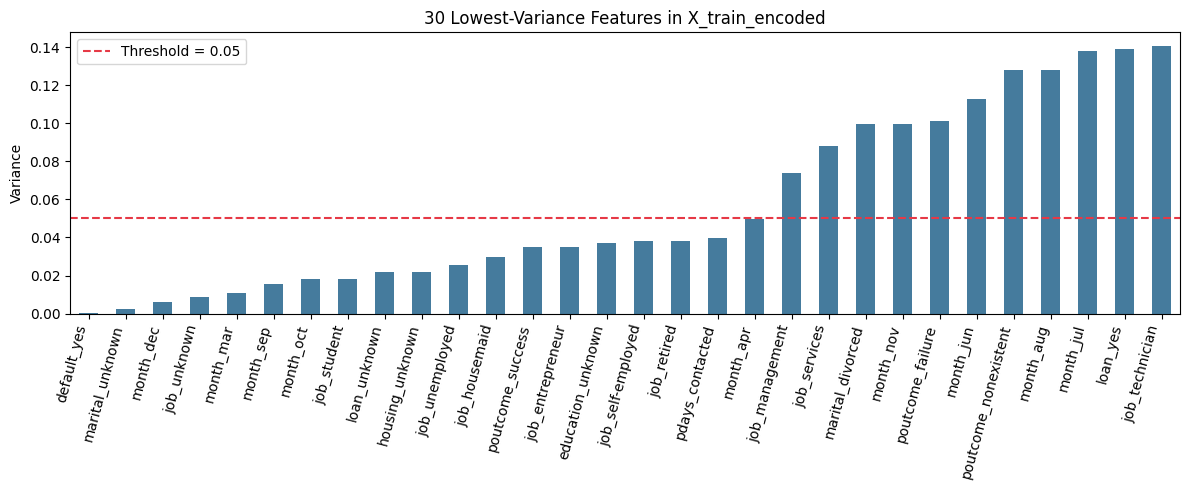


Dropped 19 low-variance features: ['default_yes', 'marital_unknown', 'month_dec', 'job_unknown', 'month_mar', 'month_sep', 'month_oct', 'job_student', 'loan_unknown', 'housing_unknown', 'job_unemployed', 'job_housemaid', 'poutcome_success', 'job_entrepreneur', 'education_unknown', 'job_self-employed', 'job_retired', 'pdays_contacted', 'month_apr']
Shapes after removal: Train (2883, 38), Test (618, 38), Val (618, 38)


In [259]:
feature_variance = X_train_encoded.var().sort_values()
lowest_variance = feature_variance.head(30)
low_variance_features = feature_variance[feature_variance < 0.05]

print('Low-variance features (threshold < 0.05):')
display(low_variance_features)

plt.figure(figsize=(12, 5))
lowest_variance.plot(kind='bar', color='#457b9d')
plt.axhline(0.05, color='#e63946', linestyle='--', label='Threshold = 0.05')
plt.ylabel('Variance')
plt.title('30 Lowest-Variance Features in X_train_encoded')
plt.xticks(rotation=75, ha='right')
plt.legend()
plt.tight_layout()
plt.show()

# Drop low-variance features from all splits
low_var_cols = low_variance_features.index.tolist()
X_train_encoded = X_train_encoded.drop(columns=low_var_cols)
X_test_encoded = X_test_encoded.drop(columns=low_var_cols)
X_val_encoded = X_val_encoded.drop(columns=low_var_cols)

print(f'\nDropped {len(low_var_cols)} low-variance features: {low_var_cols}')
print(f'Shapes after removal: Train {X_train_encoded.shape}, Test {X_test_encoded.shape}, Val {X_val_encoded.shape}')

**Removing Features with Low Variance**

I've chosen **0.05** as my variance threshold for removal. **0.05** is a commonly used threshold to remove values with a variance that's too low. In the graph above, it looks like a reasonable choice as the next feature above the threshold is almost double the threshold itself, it then only rises showing a clear separation in variance between the two sides of the threshold.

#### Removing Highly Correlated Features
When two features are highly correlated they carry near-identical information, and keeping both inflates multicollinearity — this is particularly problematic for logistic regression where coefficient estimates become unstable. Below I compute the absolute pairwise correlation matrix on numerical training features and flag pairs above a threshold of **0.6**.

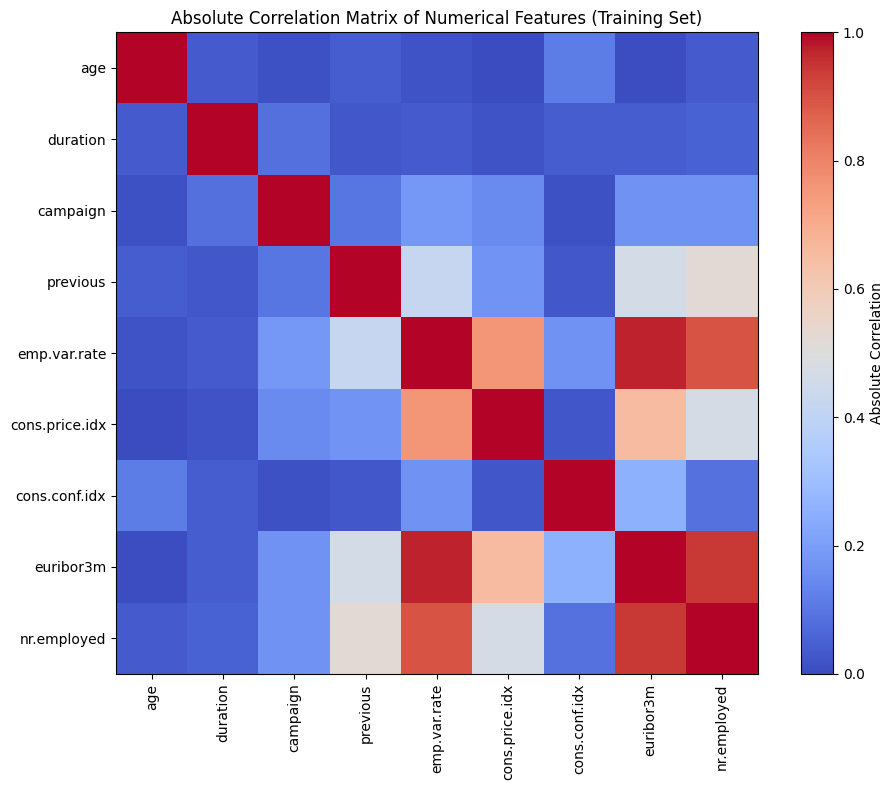

Highly correlated numerical feature pairs (>|0.6|):


,Feature 1,Feature 2,Absolute Correlation
43,emp.var.rate,euribor3m,0.969648
71,euribor3m,nr.employed,0.942087
44,emp.var.rate,nr.employed,0.895815
41,emp.var.rate,cons.price.idx,0.756447
52,cons.price.idx,euribor3m,0.654637


Recommended feature(s) to remove:
['euribor3m', 'emp.var.rate']

Shapes after removing highly correlated features:
X_train_selected: (2883, 36)
X_test_selected: (618, 36)
X_val_selected: (618, 36)


In [260]:
train_numeric = X_train_encoded[numerical_features.intersection(X_train_encoded.columns)].copy()
correlation_matrix = train_numeric.corr().abs()

# 1) Show the correlation matrix first
plt.figure(figsize=(10, 8))
plt.imshow(correlation_matrix, cmap='coolwarm', vmin=0, vmax=1)
plt.colorbar(label='Absolute Correlation')
plt.xticks(range(len(train_numeric.columns)), train_numeric.columns, rotation=90)
plt.yticks(range(len(train_numeric.columns)), train_numeric.columns)
plt.title('Absolute Correlation Matrix of Numerical Features (Training Set)')
plt.tight_layout()
plt.show()

# 2) Then apply a correlation threshold
correlation_threshold = 0.6
upper_triangle = correlation_matrix.where(
    np.triu(np.ones(correlation_matrix.shape), k=1).astype(bool)
)

high_correlation_pairs = (
    upper_triangle.stack()
    .reset_index()
    .rename(columns={'level_0': 'Feature 1', 'level_1': 'Feature 2', 0: 'Absolute Correlation'})
)
high_correlation_pairs = high_correlation_pairs[
    high_correlation_pairs['Absolute Correlation'] > correlation_threshold
].sort_values('Absolute Correlation', ascending=False)

print(f'Highly correlated numerical feature pairs (>|{correlation_threshold}|):')
display(high_correlation_pairs)

# Remove highly redundant macro-rate variables and keep the broader macro indicators
features_to_remove = ['euribor3m', 'emp.var.rate']
print('Recommended feature(s) to remove:')
print(features_to_remove)

# Apply the removal to all encoded splits
X_train_selected = X_train_encoded.drop(columns=features_to_remove, errors='ignore')
X_test_selected = X_test_encoded.drop(columns=features_to_remove, errors='ignore')
X_val_selected = X_val_encoded.drop(columns=features_to_remove, errors='ignore')

print('\nShapes after removing highly correlated features:')
print(f'X_train_selected: {X_train_selected.shape}')
print(f'X_test_selected: {X_test_selected.shape}')
print(f'X_val_selected: {X_val_selected.shape}')


**Removing Highly Correlated Numerical Features**

I created a matrix to visualize correlation, I could see very high correlation between **emp.var.rate**, **euribor3m** and **nr.employed**. I chose to keep **nr.employed** as removing the other two would remove correlation related to it as well as because the other two values also have relatively high correlations to cons.price.idx.

**Features to be Removed Based on Conceptual Consideration**

duration
- duration is only known after the call ends as it is the length of the call, this is clear data leakage as we are predicting which clients will subscribe before the call starts.
- it must be removed

In [261]:
# Remove duration due to leakage risk (not available before call outcome)

for split_name in ['X_train_selected', 'X_test_selected', 'X_val_selected']:
    if split_name in globals():
        globals()[split_name] = globals()[split_name].drop(columns=['duration'], errors='ignore')
    else:
        # Fallback in case selected datasets were not created yet
        base_name = split_name.replace('_selected', '_encoded')
        globals()[split_name] = globals()[base_name].drop(columns=['duration'], errors='ignore')

print('Shapes after removing duration:')
print(f"X_train_selected: {X_train_selected.shape}")
print(f"X_test_selected: {X_test_selected.shape}")
print(f"X_val_selected: {X_val_selected.shape}")

Shapes after removing duration:
X_train_selected: (2883, 35)
X_test_selected: (618, 35)
X_val_selected: (618, 35)


#### Why Feature Selection Must Use Training Data Only

Feature selection should only be done on the training set. The reason is that this step uses the relationship between features and the target, so if we use the full dataset before splitting, we are letting validation and test targets influence what features are chosen resulting in target leakage. It can make our scores look better than they are and lower generalization. To avoid that, we fit feature selection on training only, then apply the same selected features to validation and test without refitting.

## Task 8: Feature Scaling

Logistic regression is sensitive to the scale of its inputs — features with larger ranges would dominate the gradient updates. Scaling ensures all features contribute proportionally during training.

**Features to Scale**

All continuous variables must be scaled, this includes:
- age
- campaign
- pdays
- previous
- cons.price.idx
- cons.conf.idx
- nr.employed
- education_encoded (the ordinal encoded feature)

Binary one-hot columns are excluded because they are already 0/1 and standardizing them would distort their interpretability without improving model performance.

**Standardization or Normalization?**

Standardization will be used as it works better for logistic regression due to the fact that it handles outliers better and is centered around 0 which significantly improves performance of gradient descent. It transforms each feature using $z = \frac{x - \mu}{\sigma}$ so that the result has mean 0 and standard deviation 1. Normalization was not chosen because it's sensitive to outliers — and several features like **pdays** and **campaign** have outlier-like values that would compress the rest of the distribution.

In [262]:
from sklearn.preprocessing import StandardScaler

# Use the feature-selected datasets if they exist; otherwise fall back to encoded datasets.
if 'X_train_selected' in globals():
    X_train_base = X_train_selected.copy()
    X_test_base = X_test_selected.copy()
    X_val_base = X_val_selected.copy()
else:
    X_train_base = X_train_encoded.copy()
    X_test_base = X_test_encoded.copy()
    X_val_base = X_val_encoded.copy()

# Scale continuous/ordinal numeric features only (not one-hot binary columns).
features_to_scale = [
    'age',
    'campaign',
    'pdays',
    'previous',
    'cons.price.idx',
    'cons.conf.idx',
    'nr.employed',
    'education_encoded'
]
features_to_scale = [col for col in features_to_scale if col in X_train_base.columns]

scaler = StandardScaler()

X_train_scaled = X_train_base.copy()
X_test_scaled = X_test_base.copy()
X_val_scaled = X_val_base.copy()

X_train_scaled[features_to_scale] = scaler.fit_transform(X_train_base[features_to_scale])
X_test_scaled[features_to_scale] = scaler.transform(X_test_base[features_to_scale])
X_val_scaled[features_to_scale] = scaler.transform(X_val_base[features_to_scale])

print('Scaled features:')
print(features_to_scale)
print('\nShapes after standardization:')
print(f'X_train_scaled: {X_train_scaled.shape}')
print(f'X_test_scaled: {X_test_scaled.shape}')
print(f'X_val_scaled: {X_val_scaled.shape}')

display(X_train_scaled.head())

Scaled features:
['age', 'campaign', 'previous', 'cons.price.idx', 'cons.conf.idx', 'nr.employed', 'education_encoded']

Shapes after standardization:
X_train_scaled: (2883, 35)
X_test_scaled: (618, 35)
X_val_scaled: (618, 35)


,age,campaign,previous,cons.price.idx,cons.conf.idx,nr.employed,education_encoded,job_admin.,job_blue-collar,job_management,...,month_jun,month_may,month_nov,day_of_week_fri,day_of_week_mon,day_of_week_thu,day_of_week_tue,day_of_week_wed,poutcome_failure,poutcome_nonexistent
1948,0.849392,2.080561,-0.357112,-0.233416,0.937292,0.842054,0.524784,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,1.0
2198,0.366946,-0.209287,-0.357112,0.576339,-0.488655,0.842054,-1.581660,0.0,0.0,0.0,...,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,1.0
166,-0.790923,-0.209287,-0.357112,-1.174714,-1.244839,-0.900585,1.051395,1.0,0.0,0.0,...,0.0,1.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,1.0
2152,0.366946,-0.590929,-0.357112,-0.650252,-0.337418,0.405719,-0.528438,0.0,1.0,0.0,...,0.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0,0.0,1.0
2881,-0.694434,-0.590929,-0.357112,-1.174714,-1.244839,-0.900585,-0.001827,1.0,0.0,0.0,...,0.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,1.0


#### Result

StandardScaler was fitted on the training set (`fit_transform`) and then applied to validation and test sets (`transform` only). This ensures scaling parameters (mean, standard deviation) come exclusively from training data, preventing any information from evaluation data leaking into preprocessing.

## Task 9: Addressing Class Imbalance

There must be enough representation of both target values before we can train or there will be bias towards the values which has more representation.

**Chosen strategy: Random oversampling**

I'm using random oversampling because it doesn't make assumptions about the minority class. It doesn't try to create new fake data points between existing ones, which is useful here because our features are a mix of scaled numbers, ordinal values and a bunch of binary one-hot columns. SMOTE or ADASYN would try to interpolate between minority examples and that doesn't really work well when most of the features are just 0s and 1s.

For logistic regression, the idea is that the model sees the minority class more often during training so it pays more attention to `yes` cases. This should reduce how much the model leans towards always predicting `no` and improve recall for subscribers. The downside is that duplicating minority examples can lead to overfitting, but for a baseline model it's a straightforward way to balance things out.

**Where it belongs in the pipeline**

Resampling must happen after feature selection and feature scaling, but before model training. It must only be applied to the training set. If resampling is done before the split, or applied to validation and test sets, information from duplicated minority examples leaks into evaluation and makes performance look better than it really is.

If resampling were done before splitting, duplicated minority examples could end up in both the training and evaluation sets. That means the model would be tested on data it's already seen, which would make our metrics look better than they actually are.

**Effect on evaluation metrics**

With class imbalance, accuracy can be misleading because a model may score highly just by predicting the majority class most of the time. Precision becomes important because it tells us how many predicted `yes` cases are actually correct, while recall tells us how many real `yes` cases the model successfully finds. In this task, recall is especially important because missing likely subscribers reduces the value of the model, but precision still matters because too many false positives would waste marketing effort.

In [263]:
# Quantify class imbalance in the training set
train_class_counts = y_train.value_counts().sort_index()
train_class_pct = (y_train.value_counts(normalize=True).sort_index() * 100).round(2)

train_distribution = pd.DataFrame({
    'Count': train_class_counts,
    'Percentage (%)': train_class_pct
})

print('Training set class distribution before resampling:')
display(train_distribution)

print('Why this matters:')
print("The positive class ('yes') is the minority class, so a model can get high accuracy by over-predicting 'no'.")
print("For this task that is a problem, because the useful outcome is identifying likely subscribers rather than only maximizing accuracy.")

# Apply random oversampling to the training set only
X_resample_source = X_train_scaled.copy() if 'X_train_scaled' in globals() else X_train_selected.copy()
resample_train = X_resample_source.copy()
resample_train['y'] = y_train.values

majority_class = y_train.value_counts().idxmax()
minority_class = y_train.value_counts().idxmin()
majority_df = resample_train[resample_train['y'] == majority_class]
minority_df = resample_train[resample_train['y'] == minority_class]

minority_oversampled = minority_df.sample(
    n=len(majority_df),
    replace=True,
    random_state=42
)

resampled_train = pd.concat([majority_df, minority_oversampled], axis=0).sample(frac=1, random_state=42)

X_train_resampled = resampled_train.drop(columns='y').reset_index(drop=True)
y_train_resampled = resampled_train['y'].reset_index(drop=True)

resampled_counts = y_train_resampled.value_counts().sort_index()
resampled_pct = (y_train_resampled.value_counts(normalize=True).sort_index() * 100).round(2)
resampled_distribution = pd.DataFrame({
    'Count': resampled_counts,
    'Percentage (%)': resampled_pct
})

print('\nTraining set class distribution after random oversampling:')
display(resampled_distribution)

print(f'Original training shape: {X_resample_source.shape}')
print(f'Resampled training shape: {X_train_resampled.shape}')

Training set class distribution before resampling:


,Count,Percentage (%)
y,,
no,2567,89.04
yes,316,10.96


Why this matters:
The positive class ('yes') is the minority class, so a model can get high accuracy by over-predicting 'no'.
For this task that is a problem, because the useful outcome is identifying likely subscribers rather than only maximizing accuracy.

Training set class distribution after random oversampling:


,Count,Percentage (%)
y,,
no,2567,50.0
yes,2567,50.0


Original training shape: (2883, 35)
Resampled training shape: (5134, 35)


#### Resampling Result
After random oversampling, the training set is balanced at 50/50 between `yes` and `no`. The training set has grown from its original size to roughly double as the minority class was duplicated up to match the majority. Validation and test sets remain untouched — they still reflect the original class distribution so that evaluation stays realistic.

## Task 10: Training a Baseline Logistic Regression Model

With the training data cleaned, encoded, selected, scaled, and resampled, I can now train a logistic regression model as a baseline. I evaluate on the *validation* set (not test) to preserve the test set for final evaluation. I also compare against a Zero Rule baseline (always predict the majority class) to verify the model is actually learning meaningful patterns rather than just defaulting to 'no'.

Validation set performance:


,Metric,Value
0,Accuracy,0.791262
1,Precision,0.265152
2,Recall,0.522388
3,F1 Score,0.351759
4,ROC-AUC,0.750576


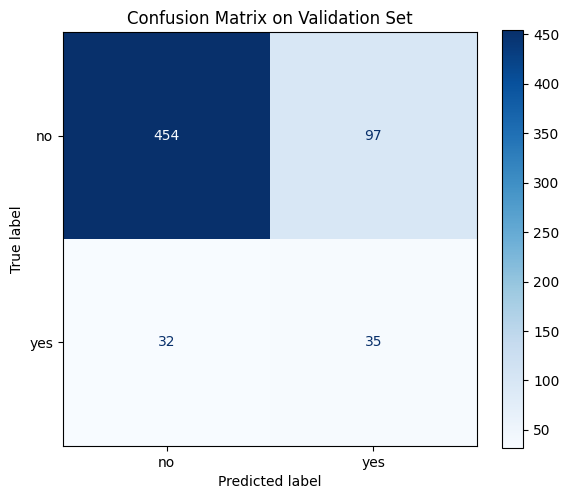

Zero Rule baseline class: no
Zero Rule baseline accuracy: 0.8916
Logistic Regression accuracy: 0.7913
Interpretation: The logistic regression model does not beat the Zero Rule baseline on validation accuracy, so the current setup is not yet better than always predicting the majority class.


In [264]:
# Use resampled training data if available; otherwise fall back to the scaled training set.
if 'X_train_resampled' in globals() and 'y_train_resampled' in globals():
    X_train_model = X_train_resampled.copy()
    y_train_model = y_train_resampled.copy()
else:
    X_train_model = X_train_scaled.copy()
    y_train_model = y_train.copy()

X_val_model = X_val_scaled.copy()
y_val_model = y_val.copy()

# Train logistic regression
log_reg_model = LogisticRegression(max_iter=2000, random_state=42)
log_reg_model.fit(X_train_model, y_train_model)

# Generate validation predictions and predicted probabilities
y_val_pred = log_reg_model.predict(X_val_model)
y_val_proba = log_reg_model.predict_proba(X_val_model)[:, 1]  # probability of 'yes'

# Validation metrics
val_accuracy = accuracy_score(y_val_model, y_val_pred)
val_precision = precision_score(y_val_model, y_val_pred, pos_label='yes')
val_recall = recall_score(y_val_model, y_val_pred, pos_label='yes')
val_f1 = f1_score(y_val_model, y_val_pred, pos_label='yes')
val_roc_auc = roc_auc_score((y_val_model == 'yes').astype(int), y_val_proba)

metrics_df = pd.DataFrame({
    'Metric': ['Accuracy', 'Precision', 'Recall', 'F1 Score', 'ROC-AUC'],
    'Value': [val_accuracy, val_precision, val_recall, val_f1, val_roc_auc]
})

print('Validation set performance:')
display(metrics_df)

# Confusion matrix
cm = confusion_matrix(y_val_model, y_val_pred, labels=['no', 'yes'])
fig, ax = plt.subplots(figsize=(6, 5))
ConfusionMatrixDisplay(cm, display_labels=['no', 'yes']).plot(ax=ax, cmap='Blues')
ax.set_title('Confusion Matrix on Validation Set')
plt.tight_layout()
plt.show()

# Zero Rule baseline: always predict the majority class from the training set
zero_rule_class = y_train.value_counts().idxmax()
zero_rule_pred = pd.Series(zero_rule_class, index=y_val_model.index)
zero_rule_accuracy = accuracy_score(y_val_model, zero_rule_pred)

print(f"Zero Rule baseline class: {zero_rule_class}")
print(f"Zero Rule baseline accuracy: {zero_rule_accuracy:.4f}")
print(f"Logistic Regression accuracy: {val_accuracy:.4f}")

if val_accuracy > zero_rule_accuracy:
    print('Interpretation: The logistic regression model outperforms the Zero Rule baseline on validation accuracy, so it is learning patterns beyond always predicting the majority class.')
elif val_accuracy < zero_rule_accuracy:
    print('Interpretation: The logistic regression model does not beat the Zero Rule baseline on validation accuracy, so the current setup is not yet better than always predicting the majority class.')
else:
    print('Interpretation: The logistic regression model matches the Zero Rule baseline on validation accuracy, so it is not yet showing an advantage over the simplest baseline.')


### Interpretation of Results

**Accuracy (0.79) vs Zero Rule Baseline (0.89)**
- The model's accuracy is lower than the Zero Rule baseline that predicts **no** every time. This looks worse than it really is, random oversampling made the model to pay more attention to the minority class, so it now predicts 'yes' more often. That means it gets some 'no' cases wrong (97 false positives in the confusion matrix), which drops overall accuracy. Although our accuracy is worse, the model has started to do it's job.

**Precision (0.27)**
- Of all the clients the model predicted would subscribe, only about 27% actually did. This means roughly 3 out of 4 predicted subscribers are false alarms. In a real marketing context this means the bank would be wasting effort contacting a lot of people who won't subscribe. This could be because the oversampling added extra minority examples without adding new information, we can assume that the model focused too much on the noice rather than making connections to the values.

**Recall (0.52)**
- The model catches about half of the actual subscribers. This is a meaningful improvement over the Zero Rule baseline which catches none of them. However, it still misses roughly half, 32 out of 67 real subscribers were predicted as 'no'. This is obviously not ideal for a real company as it could mean losing half of your potential revenue.

**F1 Score (0.35)**
- The F1 score combines precision and recall into a single number. At 0.35 it confirms what we already see: the model is making progress but neither precision nor recall are strong enough on their own. The low F1 tells us the model is struggling to be both selective (precision) and thorough (recall) at the same time. This suggests the current feature set and simple oversampling aren't enough to confidently identify subscribers.

**ROC-AUC (0.75)**
- This is our best metric. A ROC-AUC of 0.75 means the model has genuine discriminative ability, it ranks actual subscribers higher than non-subscribers 75% of the time, well above the 0.5 that random guessing would give. This tells us the data preparation pipeline is working: the features we kept do carry useful signal, and the model is picking up on it. The gap between a decent ROC-AUC and a poor F1/precision suggests the tuning default values in the logistic regression model could show vast improvements in precision and recall (and obviously F1 Score in this case) without changing too much in the pipeline.

**Confusion Matrix**
- 454 true negatives: the model correctly identifies most non-subscribers
- 97 false positives: the main source of error — clients predicted to subscribe who didn't. This is where the low precision comes from
- 32 false negatives: real subscribers the model missed
- 35 true positives: real subscribers the model correctly found
- The false positive count (97) is almost 3x the true positive count (35), which explains why precision is so low. This may be fixed by increasing the decision threshold of our model.

**What this means for the data preparation pipeline**
- The pipeline itself (splitting, encoding, scaling, feature selection) is decent. We avoided data leakage and the model is actually learning, confirmed by our ROC-AUC value.
- Random oversampling did its job of making the model aware of the minority class, but the simple duplication of minority samples may be contributing to the high false positive rate. More sophisticated resampling (SMOTE, ADASYN) or adjusting the classification threshold could help
- The remaining features after selection carry enough signal for the model to distinguish between classes at a broad level, but not enough for highly precise predictions at the default threshold

## Final Notes from Me

#### AI Usages
- Most of the code in this assignment was generated by using github copilot in my IDE. It used a range of differenent Agents using different models from but Claude (Opus, Sonnet) and OpenAI (Codex)
- The actual architecture, the graphs, distributions, the way it managed missing values, how it encoded values, how it split data, etc. Was done by me. This took some looking through the slides and researching such as: **When modelling the distribution of different data types, what plots work best**
- Sometimes I was curious about something but didn't fully understand it, such as how a distribution was behaving, and found the easiest thing to do was to screenshot it and ask an LLM (OpenAI)

#### What I got from the project
I think the biggest take away from the project was putting the practice to work. Learning in the classroom only gives you information but it's the doing that cements it. I made myself an initial order at the start of the project to get me going which was simply wrong and it's so much easier to see in hindsight because I understand these steps more now.

My one regret was leaving it until so late, there were multiple times I wanted to start earlier but got scared off by the workload and feeling like I didn't know how to do anything. This caused a bit (a lot) of a cram at the end of the project. When I finally made it to the interpretation of results at the end, I could see the things I wanted to test and change but I simply didn't have time to implement them.